In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/house_prices.csv')
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.shape

(187531, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

In [5]:
df.isna().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

The data contains 187531 rows

(Index , Price (in rupees), Dimensions, Plot Area) these are the numeric columns and the rest is text

The Plot Area and Dimensions are all Nulls making them the most missing valued columns


In [6]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

df.drop(columns=["Amount(in rupees)",'Index', 'Title', 'Description'], inplace=True)

In [7]:
def clean_area_column(series):
    # 1. Convert to lower case and strip spaces
    s = series.astype(str).str.lower().str.strip()

    # 2. Extract numerical values using Pandas string extraction
    numbers = s.str.extract(r"([\d\.]+)")[0].astype(float)

    # 3. Create conversion factors based on units present in the string
    multiplier = np.ones(len(series))
    multiplier = np.where(s.str.contains("sqm|sq.m", na=False), 10.764, multiplier)
    multiplier = np.where(s.str.contains("sqyrd|sq.yd", na=False), 9.0, multiplier)

    # 4. Calculate total sqft and handle non-numeric/missing rows
    result = numbers * multiplier
    return result

# Clean Carpet Area
if "Carpet Area" in df.columns:
    df["carpet_area_sqft"] = clean_area_column(df["Carpet Area"])

# Clean Super Area
if "Super Area" in df.columns:
    df["super_area_sqft"] = clean_area_column(df["Super Area"])

# Combine them: use Carpet Area first, fall back to Super Area if Carpet is missing
df["area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
df.drop(columns=["Carpet Area", "Super Area", "carpet_area_sqft", "super_area_sqft"], inplace=True)

In [8]:
df['Floor'].value_counts()

Floor
1 out of 4      11801
2 out of 4      11437
3 out of 4       7804
1 out of 3       6934
2 out of 3       5868
                ...  
19 out of 52        1
14 out of 42        1
39 out of 39        1
33 out of 39        1
7 out of 70         1
Name: count, Length: 938, dtype: int64

In [9]:
def clean_floor_column(series):
    # 1. Standardise text to lowercase & strip whitespace
    s = series.astype(str).str.lower().str.strip()

    # 2. Extract the first sequence of digits found before "out of" (or anywhere in string)
    floor_num = s.str.extract(r"(\d+)\s*(?:out of|$)")[0].astype(float)

    # 3. Handle Ground and Basement variations explicitly
    # Map all basement levels (Upper Basement, Lower Basement, Basement) to -1.0
    floor_num = np.where(s.str.contains("basement", na=False), -1.0, floor_num)
    floor_num = np.where(s.str.contains("ground", na=False), 0.0, floor_num)

    # 4. Extract total floors after "out of"
    total_floors = s.str.extract(r"out of\s*(\d+)")[0].astype(float)

    return floor_num, total_floors

if "Floor" in df.columns:
    df["floor_num"], df["total_floors"] = clean_floor_column(df["Floor"])

df.drop(columns=["Floor"], inplace=True)

In [10]:
cols = ["Bathroom", "Balcony", "Car Parking"]

for col in cols:
    if col in df.columns:
        # 1. Convert to string, extract numeric digits, and cast to float
        df[col] = (
            df[col]
            .astype(str)
            .str.extract(r"(\d+)")[0]
            .astype(float)
        )

# 2. Impute missing values based on feature type
# Bathroom: Median makes the most sense (most apartments have at least 1-2 bathrooms)
if "Bathroom" in df.columns:
    df["Bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())

# Balcony & Car Parking: Imputing with 0 makes sense (missing usually implies 0/none)
if "Balcony" in df.columns:
    df["Balcony"] = df["Balcony"].fillna(0)

if "Car Parking" in df.columns:
    df["Car Parking"] = df["Car Parking"].fillna(0)


In [11]:
def reduce_cardinality(series, top_n=50):
    # 1. Clean whitespace and standardise string values, fill missing with "other"
    s = series.astype(str).str.strip().replace(["nan", "None", ""], "other")

    # 2. Find the top N most frequent categories
    top_categories = s.value_counts().nlargest(top_n).index

    # 3. Replace any value not in top_categories with 'other'
    reduced_series = np.where(s.isin(top_categories), s, "other")

    return reduced_series


# 1. Apply cardinality reduction to both columns
for col in ["location", "Society"]:
    if col in df.columns:
        df[f"{col}_clean"] = reduce_cardinality(df[col], top_n=50)

In [12]:
TheseColumns = ['location_clean', 'Society_clean']

In [13]:
df["location_clean"]

0            thane
1            thane
2            thane
3            thane
4            thane
            ...   
187526    zirakpur
187527    zirakpur
187528    zirakpur
187529    zirakpur
187530    zirakpur
Name: location_clean, Length: 177847, dtype: object

In [14]:
import json

encoding_dict = {}

for col in TheseColumns:
    encoding_dict[col] = {
        value: idx
        for idx, value in enumerate(df[col].dropna().unique())
    }

    df[col] = df[col].map(encoding_dict[col])

# Save to JSON
with open("encoding_dict.json", "w", encoding="utf-8") as f:
    json.dump(encoding_dict, f, indent=4, ensure_ascii=False)

In [15]:
df["location_clean"]

0          0
1          0
2          0
3          0
4          0
          ..
187526    50
187527    50
187528    50
187529    50
187530    50
Name: location_clean, Length: 177847, dtype: int64

In [16]:
print(encoding_dict)

{'location_clean': {'thane': 0, 'navi-mumbai': 1, 'nagpur': 2, 'mumbai': 3, 'ahmedabad': 4, 'bangalore': 5, 'chennai': 6, 'gurgaon': 7, 'hyderabad': 8, 'other': 9, 'jaipur': 10, 'kolkata': 11, 'lucknow': 12, 'new-delhi': 13, 'noida': 14, 'pune': 15, 'agra': 16, 'aurangabad': 17, 'badlapur': 18, 'bhiwadi': 19, 'bhubaneswar': 20, 'chandigarh': 21, 'coimbatore': 22, 'dehradun': 23, 'faridabad': 24, 'ghaziabad': 25, 'goa': 26, 'greater-noida': 27, 'guntur': 28, 'guwahati': 29, 'jamshedpur': 30, 'kalyan': 31, 'kanpur': 32, 'kochi': 33, 'mangalore': 34, 'mohali': 35, 'nashik': 36, 'palghar': 37, 'panchkula': 38, 'patna': 39, 'raipur': 40, 'ranchi': 41, 'siliguri': 42, 'sonipat': 43, 'surat': 44, 'thrissur': 45, 'vadodara': 46, 'varanasi': 47, 'vijayawada': 48, 'visakhapatnam': 49, 'zirakpur': 50}, 'Society_clean': {'other': 0, 'Nebula Tower': 1, 'Godrej Aria': 2, 'BPTP Terra': 3, 'Shree Vardhman Victoria': 4, 'DLF Skycourt': 5, 'Ireo Victory Valley': 6, 'SS The Coralwood': 7, 'Malibu Town': 

In [17]:
df['Status'].value_counts()

Status
Ready to Move    177252
Name: count, dtype: int64

In [18]:
df['Transaction'] = df['Transaction'].fillna('Other')
df['Transaction'].value_counts()

Transaction
Resale          135630
New Property     41445
Other              770
Rent/Lease           2
Name: count, dtype: int64

In [19]:
TheseColumns = ['Transaction']
for i in TheseColumns:
    Dict = {i:j for i,j in zip(df[i].unique(), range(len(df[i].unique())))}
    df[i] = df[i].map(Dict)

In [20]:
df['Furnishing'].value_counts()

Furnishing
Semi-Furnished    82868
Unfurnished       73491
Furnished         19421
Name: count, dtype: int64

In [21]:
df['facing'].value_counts()

facing
East            52244
North - East    23349
North           15302
West             8474
South            4316
North - West     3803
South - East     2571
South -West      2052
Name: count, dtype: int64

In [22]:
df['overlooking'].value_counts()

overlooking
Main Road                         29683
Garden/Park, Main Road            26351
Garden/Park                       22833
Garden/Park, Pool, Main Road      12285
Pool, Garden/Park, Main Road       3402
Garden/Park, Pool                  2842
Main Road, Garden/Park, Pool       1353
Pool, Main Road                    1131
Pool                                999
Main Road, Garden/Park              651
Pool, Garden/Park                   424
Garden/Park, Main Road, Pool         37
Main Road, Pool                      11
Main Road, Pool, Garden/Park          8
Pool, Main Road, Garden/Park          6
Main Road, Not Available              4
Garden/Park, Not Available            1
Pool, Main Road, Not Available        1
Name: count, dtype: int64

In [23]:
df.drop(columns=[ "Society","Dimensions", "Plot Area","Status","overlooking"], inplace=True)

In [24]:
df.isna().sum()

Price (in rupees)     7981
location                 0
Transaction              0
Furnishing            2067
facing               65736
Bathroom                 0
Balcony                  0
Car Parking              0
Ownership            61925
price_clean              0
area_sqft               90
floor_num             6949
total_floors          6995
location_clean           0
Society_clean            0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price (in rupees)  169866 non-null  float64
 1   location           177847 non-null  object 
 2   Transaction        177847 non-null  int64  
 3   Furnishing         175780 non-null  object 
 4   facing             112111 non-null  object 
 5   Bathroom           177847 non-null  float64
 6   Balcony            177847 non-null  float64
 7   Car Parking        177847 non-null  float64
 8   Ownership          115922 non-null  object 
 9   price_clean        177847 non-null  float64
 10  area_sqft          177757 non-null  float64
 11  floor_num          170898 non-null  float64
 12  total_floors       170852 non-null  float64
 13  location_clean     177847 non-null  int64  
 14  Society_clean      177847 non-null  int64  
dtypes: float64(8), int64(3), object(4)
memory usage: 21.7+ M

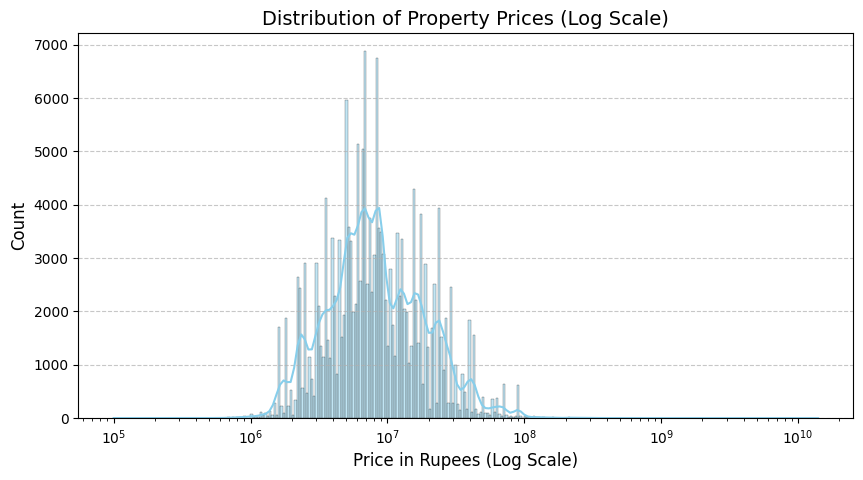

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price_clean"], log_scale=True, kde=True, color="skyblue")

plt.title("Distribution of Property Prices (Log Scale)", fontsize=14)
plt.xlabel("Price in Rupees (Log Scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

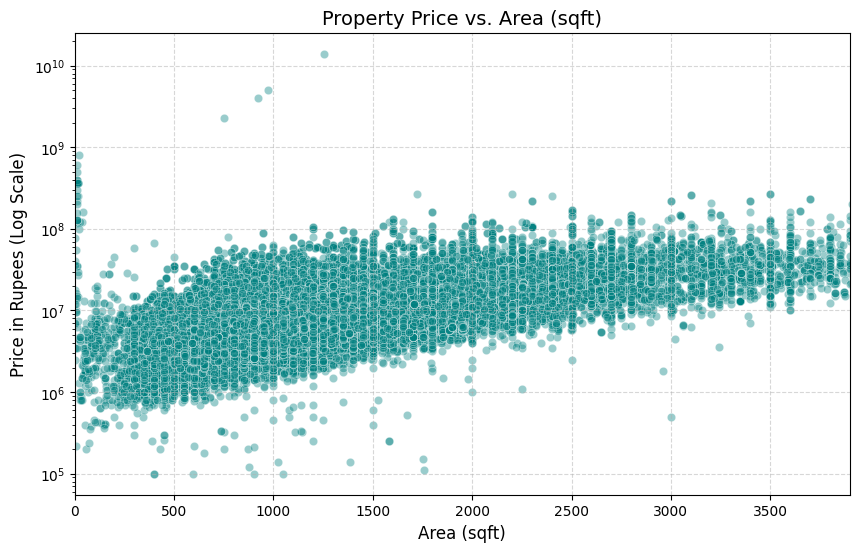

In [27]:
plt.figure(figsize=(10, 6))

# Uses area_sqft (or carpet_area_sqft if area_sqft isn't defined)
area_col = "area_sqft" if "area_sqft" in df.columns else "carpet_area_sqft"

# Scatter plot with log scale on price and percentile clip on area for visibility
sns.scatterplot(data=df, x=area_col, y="price_clean", alpha=0.4, color="teal")

plt.yscale("log")
plt.title("Property Price vs. Area (sqft)", fontsize=14)
plt.xlabel("Area (sqft)", fontsize=12)
plt.ylabel("Price in Rupees (Log Scale)", fontsize=12)

# Limit x-axis to the 99th percentile to keep extreme square footage outliers from squishing the plot
plt.xlim(0, df[area_col].quantile(0.99))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

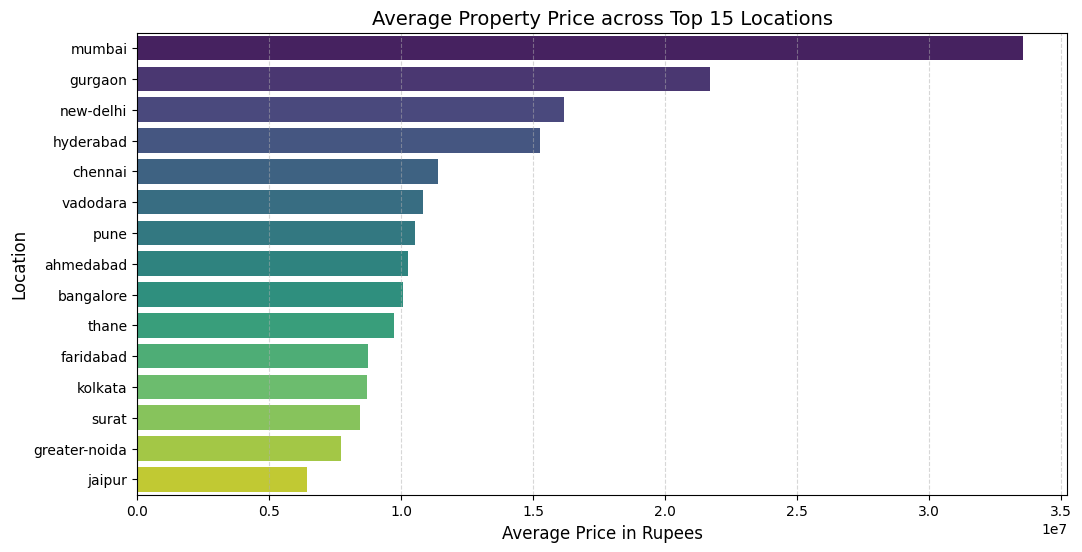

In [28]:
# 1. Identify top 15 locations by listing count
top_15_locations = df["location"].value_counts().nlargest(15).index

# 2. Filter dataset and calculate average price per location
df_top15 = df[df["location"].isin(top_15_locations)]
avg_prices = (
    df_top15.groupby("location")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 3. Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=avg_prices,
    x="price_clean",
    y="location",
    palette="viridis",
    hue="location",
    legend=False,
)

plt.title("Average Property Price across Top 15 Locations", fontsize=14)
plt.xlabel("Average Price in Rupees", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

In [29]:
df.drop(columns=[ "location"], inplace=True)

In [30]:
df.dropna(inplace=True)

TheseColumns = ['Ownership', 'Furnishing', 'facing',]
for i in TheseColumns:
    Dict = {i:j for i,j in zip(df[i].unique(), range(len(df[i].unique())))}
    df[i] = df[i].map(Dict)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101460 entries, 1 to 187530
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price (in rupees)  101460 non-null  float64
 1   Transaction        101460 non-null  int64  
 2   Furnishing         101460 non-null  int64  
 3   facing             101460 non-null  int64  
 4   Bathroom           101460 non-null  float64
 5   Balcony            101460 non-null  float64
 6   Car Parking        101460 non-null  float64
 7   Ownership          101460 non-null  int64  
 8   price_clean        101460 non-null  float64
 9   area_sqft          101460 non-null  float64
 10  floor_num          101460 non-null  float64
 11  total_floors       101460 non-null  float64
 12  location_clean     101460 non-null  int64  
 13  Society_clean      101460 non-null  int64  
dtypes: float64(8), int64(6)
memory usage: 11.6 MB


In [32]:
# Create a copy to work on
df_clean = df.copy()

# -------------------------------------------------------------------------
# 1. Price-per-sqft Outliers (Joint Price & Area Errors)
# Drops corrupted rows (e.g., 100 sqft mansions or multi-million rupee closets)
# -------------------------------------------------------------------------
df_clean["price_per_sqft"] = df_clean["price_clean"] / df_clean["area_sqft"]
p_low = df_clean["price_per_sqft"].quantile(0.01)
p_high = df_clean["price_per_sqft"].quantile(0.99)

df_clean = df_clean[
    (df_clean["price_per_sqft"] >= p_low) & (df_clean["price_per_sqft"] <= p_high)
].drop(columns=["price_per_sqft"])

# -------------------------------------------------------------------------
# 2. Extreme Area Outliers (Physical impossibility / Farmland listings)
# -------------------------------------------------------------------------
area_upper_bound = df_clean["area_sqft"].quantile(0.995)
df_clean = df_clean[
    (df_clean["area_sqft"] >= 100) & (df_clean["area_sqft"] <= area_upper_bound)
]

# -------------------------------------------------------------------------
# 3. Discrete Structural Features (Clip impossible counts instead of dropping)
# -------------------------------------------------------------------------
if "Bathroom" in df_clean.columns:
    df_clean["Bathroom"] = df_clean["Bathroom"].clip(upper=10)

if "Balcony" in df_clean.columns:
    df_clean["Balcony"] = df_clean["Balcony"].clip(upper=6)

if "Car Parking" in df_clean.columns:
    df_clean["Car Parking"] = df_clean["Car Parking"].clip(upper=10)

if "floor_num" in df_clean.columns:
    df_clean["floor_num"] = df_clean["floor_num"].clip(lower=-1, upper=80)

if "total_floors" in df_clean.columns:
    df_clean["total_floors"] = df_clean["total_floors"].clip(upper=120)

# Reset index after row dropping
df_clean = df_clean.reset_index(drop=True)

print(
    f"Outliers removed successfully!\nOriginal rows: {len(df)} -> Cleaned rows: {len(df_clean)} (Retained {len(df_clean)/len(df)*100:.2f}%)"
)

Outliers removed successfully!
Original rows: 101460 -> Cleaned rows: 99364 (Retained 97.93%)


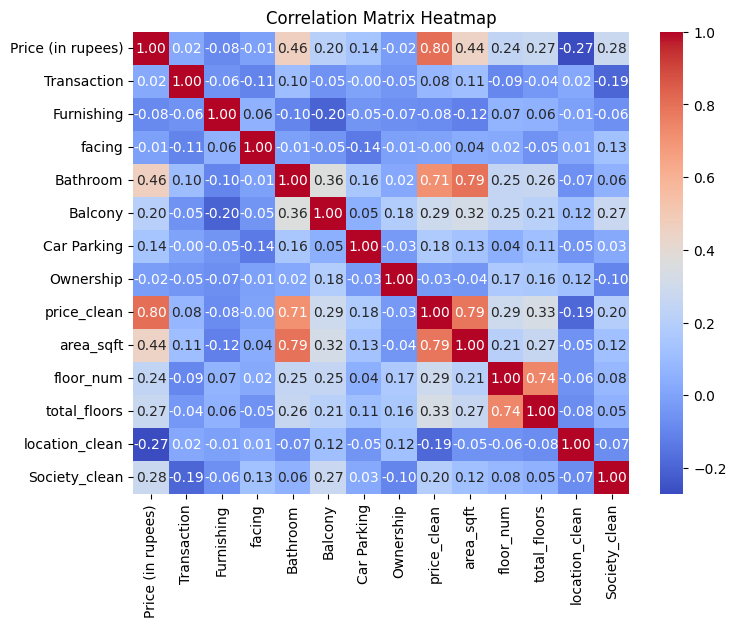

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [34]:
def get_sorted_abs_correlations(df, target_col):

    correlations = df.corr()[target_col]
    
    correlations = correlations.drop(labels=[target_col])
    
    corr_df = pd.DataFrame({
        'Feature': correlations.index,
        'Correlation': correlations.values,
        'Abs_Correlation': correlations.abs().values
    })
    
    corr_df_sorted = corr_df.sort_values(by='Abs_Correlation', ascending=False).reset_index(drop=True)
    
    display(corr_df_sorted)


# Call the function (make sure this line is flushed all the way to the left!)
get_sorted_abs_correlations(df_clean, target_col='price_clean')


,Feature,Correlation,Abs_Correlation
0,Price (in rupees),0.802582,0.802582
1,area_sqft,0.786519,0.786519
2,Bathroom,0.711956,0.711956
3,total_floors,0.334725,0.334725
4,floor_num,0.293485,0.293485
5,Balcony,0.291307,0.291307
6,Society_clean,0.195403,0.195403
7,location_clean,-0.190093,0.190093
8,Car Parking,0.175404,0.175404
9,Transaction,0.079396,0.079396


In [35]:
df_clean = df_clean.drop(columns=["Transaction", "facing", "Furnishing", "Ownership"])

In [36]:
df_clean.columns 

Index(['Price (in rupees)', 'Bathroom', 'Balcony', 'Car Parking',
       'price_clean', 'area_sqft', 'floor_num', 'total_floors',
       'location_clean', 'Society_clean'],
      dtype='object')

In [37]:
df_clean.head()

,Price (in rupees),Bathroom,Balcony,Car Parking,price_clean,area_sqft,floor_num,total_floors,location_clean,Society_clean
0,13799.0,2.0,0.0,1.0,9800000.0,473.0,3.0,22.0,0,0
1,17500.0,2.0,0.0,1.0,14000000.0,779.0,10.0,29.0,0,0
2,18824.0,2.0,0.0,1.0,16000000.0,635.0,20.0,42.0,0,0
3,6618.0,1.0,1.0,0.0,4500000.0,680.0,2.0,7.0,0,0
4,11150.0,3.0,1.0,1.0,16000000.0,900.0,3.0,27.0,0,0


In [38]:
df_clean["location_clean"].value_counts


<bound method IndexOpsMixin.value_counts of 0         0
1         0
2         0
3         0
4         0
         ..
99359    50
99360    50
99361    50
99362    50
99363    50
Name: location_clean, Length: 99364, dtype: int64>

In [39]:
df_clean.shape

(99364, 10)

In [ ]:
df.head()

,Price (in rupees),Transaction,Furnishing,facing,Bathroom,Balcony,Car Parking,Ownership,price_clean,area_sqft,floor_num,total_floors,location_clean,Society_clean
1,13799.0,0,0,0,2.0,0.0,1.0,0,9800000.0,473.0,3.0,22.0,0,0
2,17500.0,0,1,0,2.0,0.0,1.0,0,14000000.0,779.0,10.0,29.0,0,0
4,18824.0,0,1,1,2.0,0.0,1.0,1,16000000.0,635.0,20.0,42.0,0,0
5,6618.0,0,1,0,1.0,1.0,0.0,1,4500000.0,680.0,2.0,7.0,0,0
9,11150.0,0,1,0,3.0,1.0,1.0,0,16000000.0,900.0,3.0,27.0,0,0


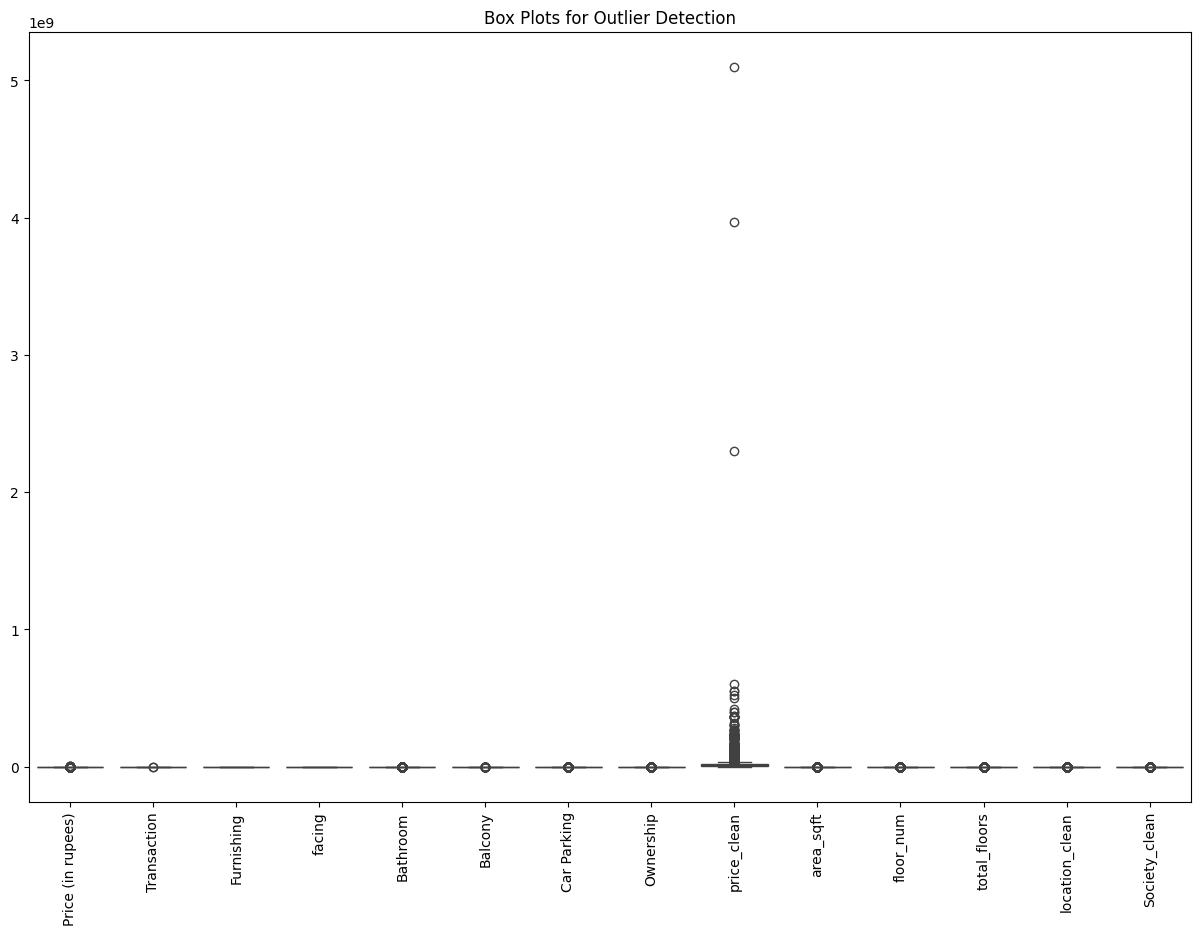

In [41]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Box Plots for Outlier Detection')
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

X = df_clean.drop(columns=["price_clean"])
y = df_clean["price_clean"]





X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
y_test.head()

65409     6000000.0
3716     13500000.0
69608    18900000.0
98107     3000000.0
61840     3000000.0
Name: price_clean, dtype: float64

In [44]:

RandomForestRegressorModel = RandomForestRegressor(n_estimators=100, random_state=42)
KNeighborsRegressorModel = KNeighborsRegressor(n_neighbors=10)

RandomForestRegressorModel.fit(X_train, y_train)
KNeighborsRegressorModel.fit(X_train, y_train)


KNeighborsRegressor(n_neighbors=10)

In [45]:
y_pred_rf = RandomForestRegressorModel.predict(X_test)
y_pred_knn = KNeighborsRegressorModel.predict(X_test)

In [46]:
accuracy_percentage = 100 - (abs(y_test - y_pred_rf) / y_test * 100)
acc = accuracy_percentage.mean()
print(f"Mean Accuracy (Random Forest): {acc:.2f}%")

accuracy_percentage = 100 - (abs(y_test - y_pred_knn) / y_test * 100)
acc = accuracy_percentage.mean()
print(f"Mean Accuracy (K-Nearest Neighbors): {acc:.2f}%")

Mean Accuracy (Random Forest): 96.86%
Mean Accuracy (K-Nearest Neighbors): 95.11%


In [47]:
MAE_Value = mean_absolute_error(y_test, y_pred_rf)
print('Mean Absolute Error(Random Forest):', MAE_Value)

MAE_Value = mean_absolute_error(y_test, y_pred_knn)
print('Mean Absolute Error(K-Nearest Neighbors):', MAE_Value)

print('*'*100)

RMSE_Value = root_mean_squared_error(y_test, y_pred_rf)
print('Root Mean Squared Error(Random Forest):', np.sqrt(RMSE_Value))

RMSE_Value = root_mean_squared_error(y_test, y_pred_knn)
print('Root Mean Squared Error(K-Nearest Neighbors):', np.sqrt(RMSE_Value))

print('*'*100)

r2 = r2_score(y_test, y_pred_rf)
print(f'R-squared(Random Forest): {r2:.4f}')

r2 = r2_score(y_test, y_pred_knn)
print(f'R-squared(K-Nearest Neighbors): {r2:.4f}')

print('*'*100)



Mean Absolute Error(Random Forest): 348031.1359913227
Mean Absolute Error(K-Nearest Neighbors): 518750.9183314044
****************************************************************************************************
Root Mean Squared Error(Random Forest): 1077.0859052539704
Root Mean Squared Error(K-Nearest Neighbors): 1288.9307054968663
****************************************************************************************************
R-squared(Random Forest): 0.9914
R-squared(K-Nearest Neighbors): 0.9825
****************************************************************************************************


In [100]:
y_train_log = np.log1p(y_train)

In [101]:

RandomForestRegressorModel_log1p = RandomForestRegressor(n_estimators=100, random_state=42)
KNeighborsRegressorModel_log1p = KNeighborsRegressor(n_neighbors=10)

RandomForestRegressorModel_log1p.fit(X_train, y_train_log)
KNeighborsRegressorModel_log1p.fit(X_train, y_train_log)

y_pred_rf_log_scale = RandomForestRegressorModel_log1p.predict(X_test)
y_pred_knn_log_scale = KNeighborsRegressorModel_log1p.predict(X_test)

y_pred_rf_log = np.expm1(y_pred_rf_log_scale)
y_pred_knn_log = np.expm1(y_pred_knn_log_scale)

In [102]:
MAE_Value = mean_absolute_error(y_test, y_pred_rf_log)
print('Mean Absolute Error(Random Forest_Logged):', MAE_Value)

MAE_Value = mean_absolute_error(y_test, y_pred_knn_log)
print('Mean Absolute Error(K-Nearest Neighbors_Logged):', MAE_Value)

print('*'*100)

RMSE_Value = root_mean_squared_error(y_test, y_pred_rf_log)
print('Root Mean Squared Error(Random Forest_Logged):', np.sqrt(RMSE_Value))

RMSE_Value = root_mean_squared_error(y_test, y_pred_knn_log)
print('Root Mean Squared Error(K-Nearest Neighbors_Logged):', np.sqrt(RMSE_Value))

print('*'*100)

r2 = r2_score(y_test, y_pred_rf_log)
print(f'R-squared(Random Forest_Logged): {r2:.4f}')

r2 = r2_score(y_test, y_pred_knn_log)
print(f'R-squared(K-Nearest Neighbors_Logged): {r2:.4f}')

print('*'*100)



Mean Absolute Error(Random Forest_Logged): 345818.49486928264
Mean Absolute Error(K-Nearest Neighbors_Logged): 511125.10526846687
****************************************************************************************************
Root Mean Squared Error(Random Forest_Logged): 1082.4144912460922
Root Mean Squared Error(K-Nearest Neighbors_Logged): 1279.5724229824095
****************************************************************************************************
R-squared(Random Forest_Logged): 0.9913
R-squared(K-Nearest Neighbors_Logged): 0.9830
****************************************************************************************************


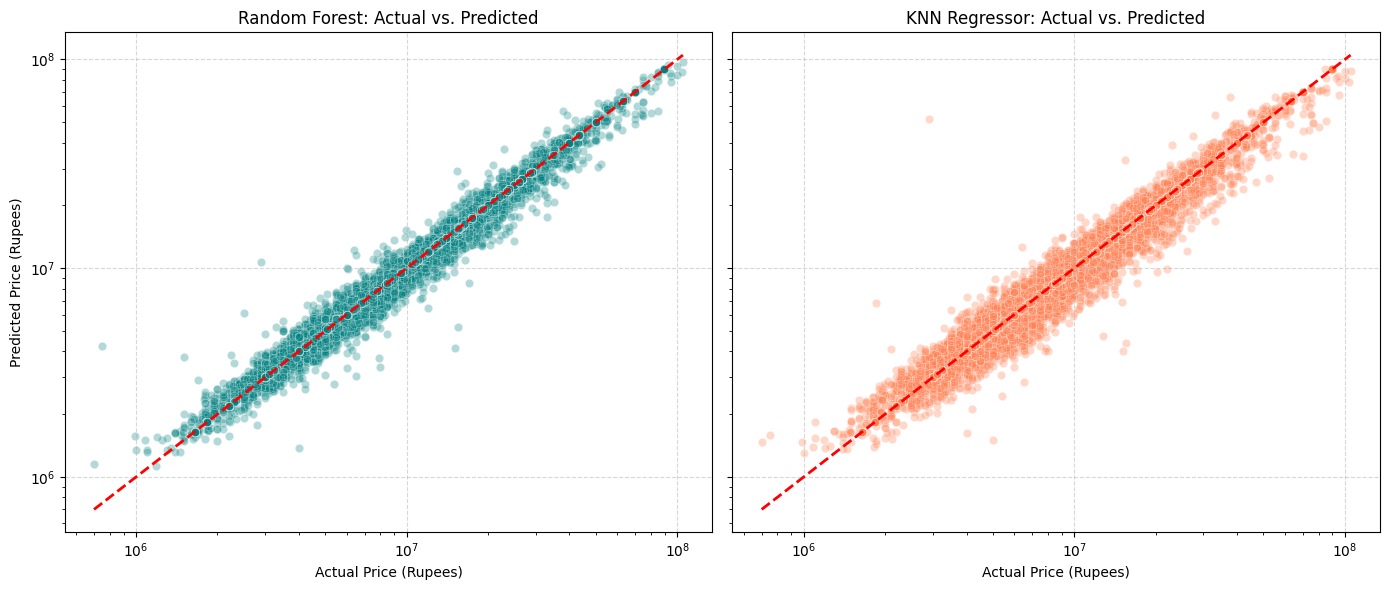

,Model,MAE,RMSE,R² Score
0,Random Forest Regressor,"359,356.91","1,085.33",0.9912
1,K-Nearest Neighbors (KNN),"510,928.70","1,276.04",0.9831


In [103]:
# 1. Define Features (X) and Target (y) using log transform
X = df_clean.drop(columns=["price_clean"])
y = df_clean["price_clean"]
y_log = np.log1p(y)

# Split into Train and Test sets
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
y_test = np.expm1(y_test_log)  # Original scale test targets

# -------------------------------------------------------------------------
# MODEL A: Random Forest Regressor
# -------------------------------------------------------------------------
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_log)

y_pred_rf_log = rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(root_mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# -------------------------------------------------------------------------
# MODEL B: K-Nearest Neighbors (KNN) Regressor
# -------------------------------------------------------------------------
knn = KNeighborsRegressor(n_neighbors=7, n_jobs=-1)
knn.fit(X_train, y_train_log)

y_pred_knn_log = knn.predict(X_test)
y_pred_knn = np.expm1(y_pred_knn_log)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(root_mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

# -------------------------------------------------------------------------
# Visualizing Predicted vs. Actual Comparison
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Random Forest Scatter Plot
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred_rf, alpha=0.3, color="teal")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Random Forest: Actual vs. Predicted", fontsize=12)
axes[0].set_xlabel("Actual Price (Rupees)", fontsize=10)
axes[0].set_ylabel("Predicted Price (Rupees)", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.5)

# KNN Scatter Plot
sns.scatterplot(ax=axes[1], x=y_test, y=y_pred_knn, alpha=0.3, color="coral")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("KNN Regressor: Actual vs. Predicted", fontsize=12)
axes[1].set_xlabel("Actual Price (Rupees)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Model Comparison Table
# -------------------------------------------------------------------------
comparison_df = pd.DataFrame(
    {
        "Model": ["Random Forest Regressor", "K-Nearest Neighbors (KNN)"],
        "MAE": [mae_rf, mae_knn],
        "RMSE": [rmse_rf, rmse_knn],
        "R² Score": [r2_rf, r2_knn],
    }
)

# Display Formatted Table
comparison_df.style.format(
    {"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R² Score": "{:.4f}"}
)

Since the MAE and RMSE of the Random Forest Regressor are lower than the ones of the KNN and the R2 score of the Random Forest Regressor is higher than that of the KNN then the Random Forest Regressor is better than the KNN for this dataset

In [104]:
import joblib
joblib.dump(RandomForestRegressorModel, "house_price_model.pkl")

['house_price_model.pkl']

In [105]:
loaded = joblib.load("house_price_model.pkl")
sample = X_test.iloc[[0]]
print(("Reloaded prediction:", loaded.predict(sample)))

('Reloaded prediction:', array([6000000.]))
